<a href="https://colab.research.google.com/github/saraalmazroa/-IT326-DataMining-Project-/blob/main/Phase2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/saraalmazroa/-IT326-DataMining-Project-/main/Dataset/german_credit_data-3.csv"
df = pd.read_csv(url)

# Phase 2

# 1-Data Analysis

## Five Number Summary, Boxplots & Outlier Detection

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# 1) Five Number Summary
numeric_cols = ['Age', 'Job', 'Credit amount', 'Duration']
print("Five Number Summary:")
df[numeric_cols].describe()

Five Number Summary:


,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


# Statistical Summary of the Numeric Attributes

Age: Values span from 19 to 75 years, clustering mainly around 27–42 (median ≈ 33, mean ≈ 35.5). A standard deviation of roughly 11 points to a moderate spread, with the applicant pool skewing toward middle age.

Job: Although coded numerically (0–3), this attribute actually represents categories of job type rather than a true numeric quantity. Given this, a bar chart is a more suitable way to visualize it than the boxplot used for the others.

Credit amount: Loan values range widely, from 250 up to 18,424, with the bulk falling between roughly 1,360 and 3,970 (median ≈ 2,320, mean ≈ 3,271). The large standard deviation (~2,820) reflects this variability, driven by a mix of modest and very large loans.

Duration: Repayment periods run from 4 to 72 months, centered around a median of 18 and a mean near 21. Most loans fall in the 12–24 month range, though a subset extends well beyond that.

*Note: Job is excluded from the outlier analysis, since it is a categorical variable represented with numeric codes rather than a genuinely continuous attribute.*

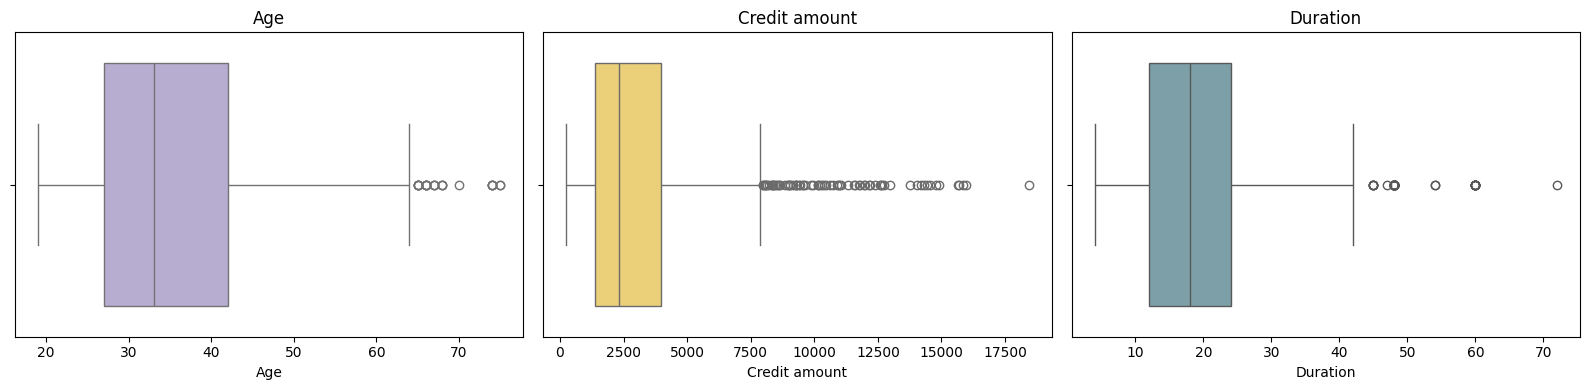

In [4]:
numeric_colums = ['Age', 'Credit amount', 'Duration']
colors = ['#B4A7D6', '#FFD966', '#76A5AF']
plt.figure(figsize=(16,4))
for i, col in enumerate(numeric_colums, 1):
  plt.subplot(1, 3, i)
  sns.boxplot(x=df[col], color=colors[i-1])
  plt.title(f'{col}')

plt.tight_layout()
plt.show()

#Age Boxplot
Most applicants are between 27–42 years old (median ≈ 33), with 23 outliers above 64.5. The moderate spread suggests normalization may help later, especially for distance-based algorithms.

# Credit Amount Boxplot
Strongly right-skewed — most loans are under ~4,000, but 72 outliers reach up to 18,424. This indicates the need for transformation (e.g., log) to prevent large values from dominating the analysis.

# *Duration Boxplot*
Similar right skew: most durations are 12–24 months, but 70 outliers extend to 72 months. This also points to needing normalization/transformation.

# Outlier Analysis Summary
Age: 2.3% outliers — minimal impact.

Credit amount: 7.2% outliers — consistent with its right-skewed distribution.

Duration: 7% outliers — also right-skewed.
All percentages are under 10%, so records will be kept and handled later via normalization/transformation rather than removed.

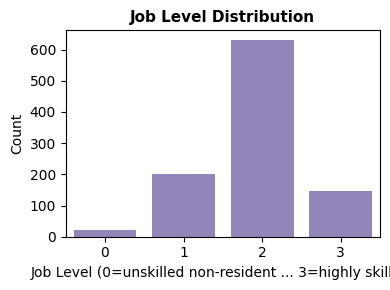

In [5]:
# 4) Job Distribution (Bar Chart) - Categorical Attribute
plt.figure(figsize=(4, 3))
sns.countplot(x=df['Job'], color='#8E7CC3')
plt.title('Job Level Distribution', fontsize=11, fontweight='bold')
plt.xlabel('Job Level (0=unskilled non-resident ... 3=highly skilled)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

Most applicants fall into category 2, with far fewer in 0, 1, and 3. This confirms Job is categorical, not continuous — it may need encoding later, and explains why IQR gave meaningless results for it.